                                                WATER MAPPING AND FLOOD DETECTION SYSTEM

PROBLEM STAEMENT : Flooding in urban areas is a major environmental and societal problem, especially during heavy rainfall and poor drainage conditions. Traditional methods of monitoring flooded areas rely on manual inspection or ground surveys, which are time-consuming and inefficient. There is a need for an automated system that can detect waterlogged regions quickly and accurately using aerial or satellite imagery. In this project, we aim to develop an image processing pipeline that can identify and segment flooded areas from RGB images. The system converts images into different color spaces to better distinguish water from land. It enhances image quality to improve visibility under poor lighting conditions and applies segmentation techniques to extract water regions. Additionally, the project analyzes flood severity using zone-based classification and generates a detailed report for decision-making. This system can assist government authorities in disaster management, urban planning, and emergency response by providing quick and reliable flood analysis.


LITERATURE REVIEW: Flood detection using satellite imagery has been widely studied in recent years, especially with the availability of remote sensing data such as Sentinel-1 and Sentinel-2. One of the important approaches is using Synthetic Aperture Radar (SAR) data, which works effectively under all weather conditions, including clouds and rain. The research paper “Surface Water Mapping and Flood Monitoring using Sentinel-1 SAR and Otsu Threshold” demonstrates how SAR images can be used to detect water bodies by analyzing backscatter values. Water surfaces appear darker in SAR images due to low reflection, which helps in distinguishing them from land areas.The paper also highlights the use of Otsu thresholding for automatic segmentation of water and non-water regions. However, instead of using a fixed threshold, the research emphasizes dynamic thresholding and time-series analysis for better accuracy. The study shows that combining preprocessing techniques such as noise reduction and filtering with threshold-based segmentation significantly improves flood detection results.In comparison, the proposed project uses RGB images and applies image processing techniques such as HSV conversion, median filtering, histogram equalization, and Otsu thresholding to detect water regions. While the research paper uses advanced SAR data, the fundamental concept of automatic thresholding and segmentation remains the same. This shows that the project is based on established research methods and can be extended further using advanced datasets like SAR imagery.


 STEP 1: Load Image

 Output: Original image displayed

Inference:

This is the input aerial image
Contains roads, land, water

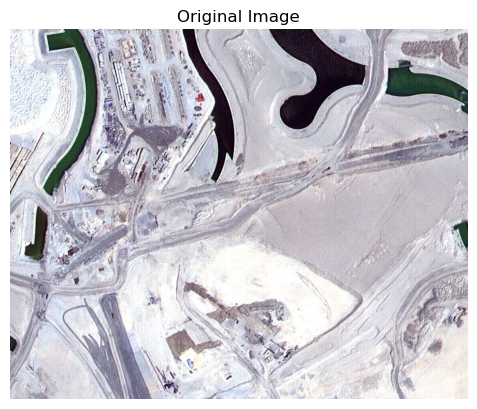

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image_part_001.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [ ]:
#STEP 2: Convert to HSV
Inference:
Image converted from RGB → HSV
Separates:
Hue (color)
Saturation
Value (brightness)
Helps in better water detection###

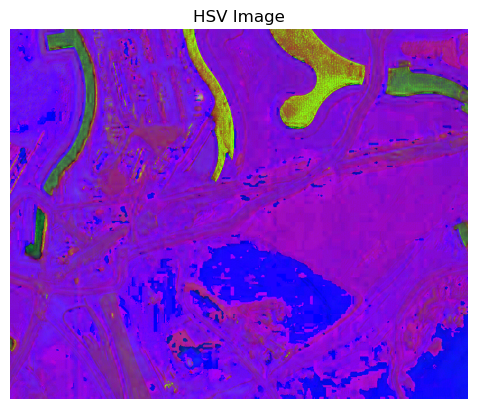

In [2]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

plt.imshow(hsv)
plt.title("HSV Image")
plt.axis('off')
plt.show()

In [ ]:
STEP:3 Extract V Channel
Inference:
Shows brightness only
Water appears:
Dark (low intensity)
Land appears:
Bright
Easier to differentiate

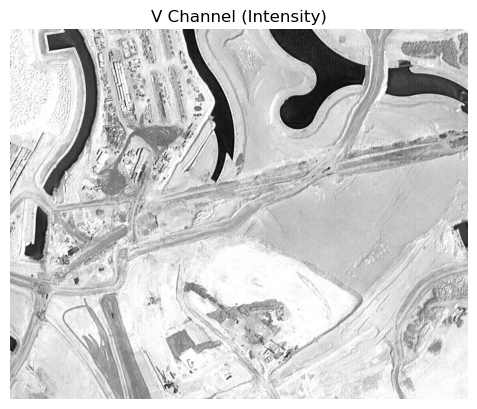

In [3]:
h, s, v = cv2.split(hsv)

plt.imshow(v, cmap='gray')
plt.title("V Channel (Intensity)")
plt.axis('off')
plt.show()

In [ ]:
STEP 4: Median Filter
Inference:
Removes noise
Smoothens image
Keeps edges intact
Improves segmentation quality

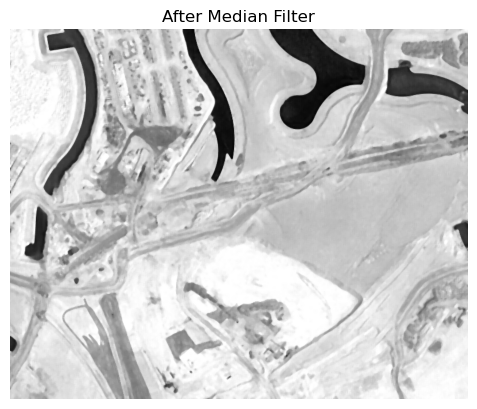

In [4]:
v_filtered = cv2.medianBlur(v, 5)

plt.imshow(v_filtered, cmap='gray')
plt.title("After Median Filter")
plt.axis('off')
plt.show()

In [ ]:
STEP 5: Histogram Equalization
Inference:
Enhances contrast
Makes water darker & land brighter
Improves visibility

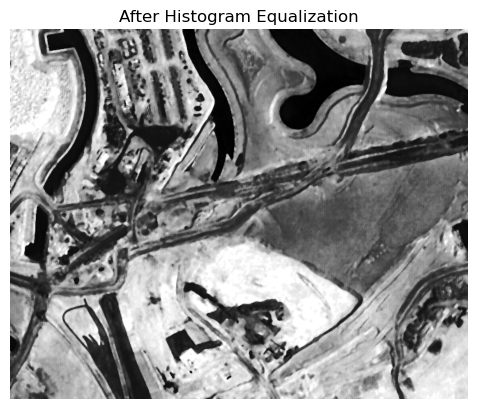

In [5]:
v_eq = cv2.equalizeHist(v_filtered)

plt.imshow(v_eq, cmap='gray')
plt.title("After Histogram Equalization")
plt.axis('off')
plt.show()

In [ ]:
# STEP6 Otsu Threshold
Inference:
Converts image → Binary
White = Water
Black = Land 
Automatic segmentation

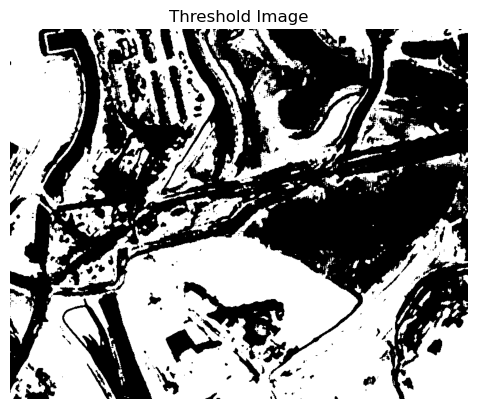

In [6]:
_, thresh = cv2.threshold(v_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold Image")
plt.axis('off')
plt.show()

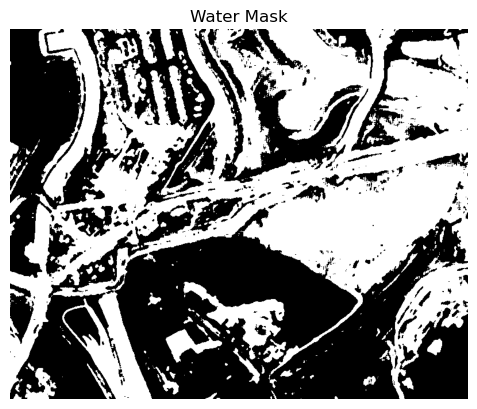

In [27]:
water_mask = cv2.bitwise_not(thresh)

plt.imshow(water_mask, cmap='gray')
plt.title("Water Mask")
plt.axis('off')
plt.show()

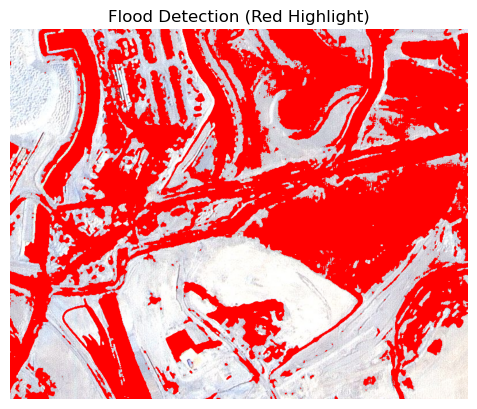

In [8]:
overlay = img.copy()
overlay[water_mask == 255] = [255, 0, 0]

plt.imshow(overlay)
plt.title("Flood Detection (Red Highlight)")
plt.axis('off')
plt.show()

In [ ]:
#STEP 7: Flood Percentage
Inference:
Calculates total white pixels
Gives % flooded area
Used for risk analysis

In [9]:
import numpy as np

water_pixels = np.sum(water_mask == 255)
total_pixels = water_mask.size

percentage = (water_pixels / total_pixels) * 100
print("Flooded Area Percentage:", percentage)

Flooded Area Percentage: 49.19398832578692


In [10]:
if percentage < 20:
    risk = "LOW"
elif percentage < 50:
    risk = "MEDIUM"
else:
    risk = "HIGH"

print("Overall Risk:", risk)

Overall Risk: MEDIUM


#STEP 8: Road Detection (Center Zone)
Inference:
Checks center region
If flooded → alert
Real-world decision support

In [14]:

h, w = water_mask.shape

center_zone = water_mask[h//4:3*h//4, w//4:3*w//4]

wp = np.sum(center_zone == 255)
tp = center_zone.size
center_perc = (wp/tp)*100

if center_perc > 40:
    print("\n ALERT: Main road may be flooded")
else:
    print("\n Roads likely clear")


 ALERT: Main road may be flooded


In [ ]:
#STEP 9: Zone Analysis
Inference:
Divides image into 4 parts
Calculates flood % in each zone
Helps identify critical areas

Zone 1: Medium (47.70%)
Zone 2: High (73.05%)
Zone 3: Medium (35.73%)
Zone 4: Medium (40.27%)


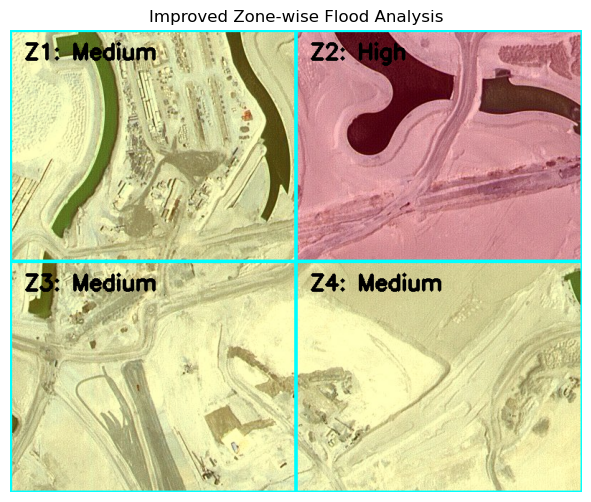

In [12]:

zone_img = img.copy()

h, w, _ = img.shape
zone_number = 1

for i in range(2):
    for j in range(2):
        
        y1, y2 = i*h//2, (i+1)*h//2
        x1, x2 = j*w//2, (j+1)*w//2
        
        zone = water_mask[y1:y2, x1:x2]
        
        # Flood %
        wp = np.sum(zone == 255)
        tp = zone.size
        perc = (wp/tp)*100
        
        # Risk classification
        if perc < 20:
            zrisk = "Low"
            color = (0,255,0)   # Green
        elif perc < 50:
            zrisk = "Medium"
            color = (255,255,0) # Yellow
        else:
            zrisk = "High"
            color = (255,0,0)   # Red
        
        
        overlay_box = zone_img.copy()
        cv2.rectangle(overlay_box, (x1,y1), (x2,y2), color, -1)
        alpha = 0.25  # transparency
        zone_img = cv2.addWeighted(overlay_box, alpha, zone_img, 1-alpha, 0)
        
       
        cv2.rectangle(zone_img, (x1,y1), (x2,y2), (0,255,255), 3)
        
        
        text = f"Z{zone_number}: {zrisk}"
        cv2.putText(zone_img, text, (x1+20, y1+40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 3)
        
        print(f"Zone {zone_number}: {zrisk} ({perc:.2f}%)")
        
        zone_number += 1


plt.figure(figsize=(8,6))
plt.imshow(zone_img)
plt.title("Improved Zone-wise Flood Analysis")
plt.axis('off')
plt.show()

In [ ]:
#STEP 9: Road Detection (Center Zone)

Inference:

Checks center region
If flooded → alert

👉 Real-world decision support

In [30]:
from datetime import datetime
import numpy as np

# -------------------------------
# ACTION FUNCTION (VERY IMPORTANT)
# -------------------------------
def action(risk):
    if risk == "High":
        return "Evacuate immediately & deploy rescue teams"
    elif risk == "Medium":
        return " Alert residents & monitor closely"
    else:
        return " Safe zone"

# -------------------------------
# REPORT START
# -------------------------------
print("\n================ FLOOD ANALYSIS REPORT ================\n")

# Date & Time
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(" Date & Time of Analysis:", current_time)

# Overall Flood Info
print(f" Total Flooded Area: {percentage:.2f}%")
print(f"Overall Risk Level: {risk}")

# -------------------------------
# RESPONSE TIME
# -------------------------------
print("\n RESPONSE TIME GUIDELINES:")

if risk == "HIGH":
    print("→ Immediate action (0–2 hours)")
elif risk == "MEDIUM":
    print("→ Action within 6–12 hours")
else:
    print("→ Monitor situation (24–48 hours)")

# -------------------------------
# ZONE-WISE ANALYSIS
# -------------------------------
print("\n ZONE-WISE ANALYSIS:")

h_img, w_img = water_mask.shape
zone_number = 1

for i in range(2):
    for j in range(2):
        
        y1, y2 = i*h_img//2, (i+1)*h_img//2
        x1, x2 = j*w_img//2, (j+1)*w_img//2
        
        zone = water_mask[y1:y2, x1:x2]
        
        wp = np.sum(zone == 255)
        tp = zone.size
        perc = (wp/tp)*100
        
        # Risk classification
        if perc < 20:
            zrisk = "Low"
        elif perc < 50:
            zrisk = "Medium"
        else:
            zrisk = "High"
        
        # Get action
        act = action(zrisk)
        
        print(f"Zone {zone_number}: {zrisk} ({perc:.2f}%) → {act}")
        
        zone_number += 1

# -------------------------------
# CENTER ROAD ANALYSIS
# -------------------------------
print("\n ROAD STATUS ANALYSIS:")

h, w = water_mask.shape
center_zone = water_mask[h//4:3*h//4, w//4:3*w//4]

wp = np.sum(center_zone == 255)
tp = center_zone.size
center_perc = (wp/tp)*100

if center_perc > 40:
    print("ALERT: Main road may be flooded")
else:
    print(" Roads likely clear")

# -------------------------------
# EMERGENCY CONTACTS
# -------------------------------
print("\n EMERGENCY CONTACTS:")
print("→ Police: 100")
print("→ Fire Brigade: 101")
print("→ Ambulance: 108")
print("→ NDMA / Disaster Management Authorities")

# -------------------------------
# FINAL SUMMARY
# -------------------------------
print("\n FINAL SUMMARY:")

if risk == "HIGH":
    print("Critical flood situation. Immediate intervention required.")
elif risk == "MEDIUM":
    print("Moderate flood risk. Preventive measures needed.")
else:
    print("Low flood risk. Situation under control.")

print("\n======================================================\n")


================ FLOOD ANALYSIS REPORT ================

 Date & Time of Analysis: 2026-04-07 16:39:42
 Total Flooded Area: 49.19%
Overall Risk Level: MEDIUM

 RESPONSE TIME GUIDELINES:
→ Action within 6–12 hours

 ZONE-WISE ANALYSIS:
Zone 1: Medium (47.70%) →  Alert residents & monitor closely
Zone 2: High (73.05%) → Evacuate immediately & deploy rescue teams
Zone 3: Medium (35.73%) →  Alert residents & monitor closely
Zone 4: Medium (40.27%) →  Alert residents & monitor closely

 ROAD STATUS ANALYSIS:
ALERT: Main road may be flooded

 EMERGENCY CONTACTS:
→ Police: 100
→ Fire Brigade: 101
→ Ambulance: 108
→ NDMA / Disaster Management Authorities

 FINAL SUMMARY:
Moderate flood risk. Preventive measures needed.




METHODOLOGY: The methodology of this project consists of multiple stages, starting from image acquisition to final flood analysis. First, the input aerial image is loaded and converted from RGB to HSV color space. This conversion helps in separating intensity and color information, making it easier to identify water regions. The V (intensity) channel is extracted as it highlights brightness differences between water and land.Next, image enhancement techniques are applied to improve the quality of the image. A median filter is used to remove noise and smooth the image without losing important edges. After that, histogram equalization is performed to enhance contrast, making water regions more distinguishable. These preprocessing steps ensure better segmentation results in the next stage.In the segmentation stage, Otsu thresholding is applied to convert the image into a binary mask, where water regions are represented as white pixels and non-water regions as black. The image is further divided into zones to analyze flood severity in different regions. Finally, a report is generated that includes flood percentage, risk level, zone-wise analysis, and suggested actions. This structured output makes the system useful for real-world applications such as disaster management

Results: The results of the project demonstrate that the system is capable of detecting flooded areas accurately from aerial images. The segmentation process successfully highlights water regions, even in complex urban environments. The zone-wise analysis provides a clear understanding of flood distribution across different parts of the image. Based on the percentage of flooded area, the system classifies the risk level into low, medium, or high categories. The generated report includes actionable insights such as emergency alerts and response time recommendations. Overall, the results show that the proposed approach is effective, efficient, and suitable for real-world flood monitoring applications